# Selecting the clustering method

**The decision.** Which grouping method, and which parameters, under the rule encoded below.
The rule's constants are declared above the scoring cells and applied before the held-out split is
opened. They are not recorded in a dated pre-result artifact, so they are reported as encoded and
applied rather than prospectively specified; Section 7.1 shows that no value of either constraint
would have changed the configuration selected.

**The evidence.** The 180 pairs annotated in `2_PairBenchmark`, split into 120 calibration pairs
that choose and 60 held-out pairs that report.

**What it produces.** `selected_clusters.csv`: one cluster label and one centrality score for each
of the 21,750 candidates. Every later notebook in the chapter reads that file.

**How to read it.** Sections 2 and 3 characterise the annotation before it decides anything.
Sections 4 and 5 score the candidates. Section 6 freezes the choice and opens the held-out pairs
once. Section 7 measures which differences the comparison was able to resolve at all, and Section 8
states the two questions this benchmark cannot answer. Section 9 renders the review material the
within-cluster audit depends on.

## 1. Configuration and the encoded selection rule

The rule is declared here as constants, before anything is computed. Later cells read
`PRECISION_TARGET` and `MAX_LARGEST_CLUSTER_FRACTION` rather than restating them, so it cannot be
adjusted after a grid has been seen without the change being visible at the top of the notebook.

- Eligible when pair precision reaches `PRECISION_TARGET` and the largest cluster stays under
  `MAX_LARGEST_CLUSTER_FRACTION` of the corpus.
- Among eligible configurations: maximise F0.5, then coverage, then recall.

F0.5 penalises a false merge four times as heavily as a missed match, because a false merge
corrupts an identity and propagates into every historical claim built on it, whereas an unassigned
candidate is merely unused. Chapter 1 selects on F2, the mirror member of the same family:
extraction is scored on recall, grouping on precision.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

from IPython.display import Image as DisplayImage

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from tqdm import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '2_clustering', \
    'Run this notebook from its own folder, 2_clustering/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
# ---------------------------------------------------------------------------
# Output versioning.
#   RUN_TAG = ''          reproduces the frozen thesis run (read-only guard on)
#   RUN_TAG = '_rerun1'   writes to a parallel directory, leaving the frozen
#                         artifacts untouched
# Input paths always point at the frozen artifacts, so a re-run is reproducible
# rather than self-referential.
# ---------------------------------------------------------------------------
RUN_TAG = '_rerun1'
ALLOW_OVERWRITE = False


def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(
            f'{path} already contains results. Set RUN_TAG to write elsewhere, '
            f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)
    return path

FEATURE_RUN_ID = 'all_regions_v1_minside24_dinov2_vitb14_binarized_v1'
FEATURE_DIR = PROJECT_DIR / 'feature_extraction_outputs' / FEATURE_RUN_ID
FEATURES_PATH = FEATURE_DIR / 'dino_features_binarized.npy'
FEATURE_MANIFEST_PATH = FEATURE_DIR / 'features_manifest.csv'

BENCHMARK_RUN_ID = f'{FEATURE_RUN_ID}_clustering_benchmark_v1'
BENCHMARK_DIR = PROJECT_DIR / '2_clustering_outputs' / BENCHMARK_RUN_ID
PAIR_CANDIDATES_PATH = BENCHMARK_DIR / 'pair_review' / 'pair_candidates.csv'
PAIR_LABELS_PATH = BENCHMARK_DIR / 'pair_review' / 'pair_review_labels.csv'
OUTPUT_DIR = BENCHMARK_DIR / f'method_comparison{RUN_TAG}'
FIGURES_DIR = OUTPUT_DIR / 'figures'
CLUSTER_SHEETS_DIR = OUTPUT_DIR / 'selected_cluster_sheets'

KNN_K = 20
PCA_DIMENSIONS = 50
PRECISION_TARGET = 0.90
MAX_LARGEST_CLUSTER_FRACTION = 0.10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

guarded_mkdir(OUTPUT_DIR)
for directory in [FIGURES_DIR, CLUSTER_SHEETS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

assert FEATURES_PATH.exists() and FEATURE_MANIFEST_PATH.exists()
assert PAIR_CANDIDATES_PATH.exists() and PAIR_LABELS_PATH.exists()
print('Feature run:', FEATURE_RUN_ID)
print('Benchmark  :', BENCHMARK_RUN_ID)
print('Device     :', DEVICE)

Feature run: all_regions_v1_minside24_dinov2_vitb14_binarized_v1
Benchmark  : all_regions_v1_minside24_dinov2_vitb14_binarized_v1_clustering_benchmark_v1
Device     : cuda


## 2. Inputs

The feature matrix from `1_FeatureExtraction`, L2 normalised so that a dot product is a cosine
similarity, and the completed annotation from `2_PairBenchmark`. The assertions below are load
bearing rather than defensive: the manifest and the matrix must agree row for row, because
everything downstream addresses crops by row index, and the annotation must be complete before
anything is scored.

In [2]:
feature_manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
feature_matrix = np.load(FEATURES_PATH, mmap_mode='r')
assert feature_matrix.shape == (len(feature_manifest), 768)
feature_norms = np.linalg.norm(feature_matrix, axis=1)
normalised_features = (
    np.asarray(feature_matrix) / feature_norms[:, None]
).astype(np.float32)

def infer_book_id(filename: str) -> str:
    stem = unicodedata.normalize('NFC', Path(filename).stem)
    if stem.upper().startswith('IMG_HDI'):
        return 'img_hdi'
    if stem.lower().startswith('vochroou70'):
        return 'vochroou70'
    return re.split(r'[.,_ \[]', stem)[0].lower()

feature_manifest['scan_id'] = feature_manifest.stem.astype(str)
feature_manifest['book_id'] = feature_manifest.filename.map(infer_book_id)

pair_candidates = pd.read_csv(PAIR_CANDIDATES_PATH)
pair_labels = pd.read_csv(PAIR_LABELS_PATH, keep_default_na=False)
assert not pair_labels.label.eq('').any(), 'Complete the pair review first.'
allowed_labels = {'same_fleuron', 'different', 'non_fleuron', 'unclear'}
assert set(pair_labels.label).issubset(allowed_labels)
reviewed_pairs = pair_candidates.merge(
    pair_labels[['pair_id', 'label', 'confidence', 'notes']],
    on='pair_id', validate='one_to_one',
)

print('Features          :', normalised_features.shape)
print('Reviewed pairs    :', len(reviewed_pairs))
print('Calibration pairs :', (reviewed_pairs.benchmark_split == 'calibration').sum())
print('Evaluation pairs  :', (reviewed_pairs.benchmark_split == 'evaluation').sum())
reviewed_pairs.label.value_counts()

Features          : (21750, 768)
Reviewed pairs    : 180
Calibration pairs : 120
Evaluation pairs  : 60


label
same_fleuron    134
non_fleuron      29
different        16
unclear           1
Name: count, dtype: int64

### 2.1 What the annotation contains

The benchmark was drawn from six cosine bands. Sampling that way is what makes a pair worth
adjudicating, since two crops taken at random are almost always an obvious non-match, and it also
determines how many negative pairs exist and where they sit. Both are properties of the annotation
rather than of any clustering method, so they are measured here, before it is used to decide
anything.

In [3]:
# Composition of the benchmark, by similarity band and by split.
label_by_band = pd.crosstab(reviewed_pairs.similarity_bin, reviewed_pairs.label)
label_by_band['total'] = label_by_band.sum(axis=1)

identity_only = reviewed_pairs[reviewed_pairs.label.isin(['same_fleuron', 'different'])]
identity_by_split = pd.crosstab(identity_only.benchmark_split, identity_only.label)

negatives = reviewed_pairs[reviewed_pairs.label == 'different']
negatives_by_band = pd.crosstab(negatives.similarity_bin, negatives.benchmark_split)

benchmark_composition = pd.DataFrame([{
    'reviewed_pairs': int(len(reviewed_pairs)),
    'identity_pairs': int(len(identity_only)),
    'positive_pairs': int(identity_only.label.eq('same_fleuron').sum()),
    'negative_pairs': int(identity_only.label.eq('different').sum()),
    'calibration_negatives': int(identity_by_split.loc['calibration', 'different']),
    'evaluation_negatives': int(identity_by_split.loc['evaluation', 'different']),
    'bands_without_a_negative': int((negatives_by_band.sum(axis=1)
                                     .reindex(label_by_band.index, fill_value=0) == 0).sum()),
    'bands_total': int(len(label_by_band)),
}])
benchmark_composition.to_csv(OUTPUT_DIR / 'benchmark_composition.csv', index=False)
label_by_band.to_csv(OUTPUT_DIR / 'benchmark_labels_by_band.csv')

print('Labels by similarity band')
display(label_by_band)
print('\nIdentity pairs by split')
display(identity_by_split)
print('\nNegatives by band and split')
display(negatives_by_band)
display(benchmark_composition.T.rename(columns={0: 'value'}))

Labels by similarity band


label,different,non_fleuron,same_fleuron,unclear,total
similarity_bin,,,,,
0.80-0.85,6,10,14,0,30
0.85-0.90,8,12,9,1,30
0.90-0.93,2,5,23,0,30
0.93-0.95,0,1,29,0,30
0.95-0.97,0,0,30,0,30
0.97-1.00,0,1,29,0,30



Identity pairs by split


label,different,same_fleuron
benchmark_split,,
calibration,11,92
evaluation,5,42



Negatives by band and split


benchmark_split,calibration,evaluation
similarity_bin,,
0.80-0.85,4,2
0.85-0.90,5,3
0.90-0.93,2,0


,value
reviewed_pairs,180
identity_pairs,150
positive_pairs,134
negative_pairs,16
calibration_negatives,11
evaluation_negatives,5
bands_without_a_negative,3
bands_total,6


**Takeaway.** The imbalance between positive and negative pairs follows from the sampling design,
not from the labelling: drawing from high-similarity bands yields pairs that are mostly genuine
matches. What matters downstream is the count rather than the ratio. Precision can be estimated
only from negative pairs, and the split that selects the method holds eleven of them.

## 3. Does the representation separate designs?

Asked before any clustering method is run. If a single global threshold on cosine similarity cannot
separate `same_fleuron` from `different`, then no method built on that similarity can either, and
any later failure would belong to the descriptor rather than to the grouping.

The threshold is not a parameter of either method below. HDBSCAN takes `min_cluster_size` and
`min_samples`, the graph method takes its own core and expansion similarities, and neither reads
this value. What this section produces is a diagnostic, a floor that a clustering method must beat
to justify its complexity, and the identity threshold reused elsewhere in the chapter whenever two
crops have to be judged the same design.

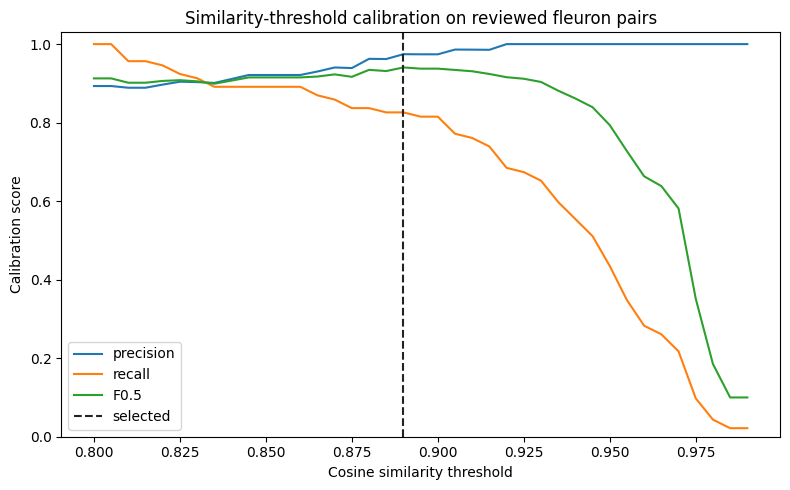

Selected threshold: 0.89
Calibration: {'precision': 0.9743589743589743, 'recall': 0.8260869565217391, 'f0_5': 0.9405940594059407}
Evaluation : {'precision': 1.0, 'recall': 0.8809523809523809, 'f0_5': 0.9736842105263159}


In [4]:
def wilson_interval(successes, total, z_score=1.96):
    if total == 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1 + z_score ** 2 / total
    centre = proportion + z_score ** 2 / (2 * total)
    margin = z_score * np.sqrt(
        proportion * (1 - proportion) / total + z_score ** 2 / (4 * total ** 2)
    )
    lower = max(0.0, (centre - margin) / denominator)
    upper = min(1.0, (centre + margin) / denominator)
    return lower, upper

def binary_metrics(true_same, predicted_same):
    true_same = np.asarray(true_same, dtype=bool)
    predicted_same = np.asarray(predicted_same, dtype=bool)
    true_positive = int(np.sum(true_same & predicted_same))
    false_positive = int(np.sum(~true_same & predicted_same))
    false_negative = int(np.sum(true_same & ~predicted_same))
    true_negative = int(np.sum(~true_same & ~predicted_same))
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    precision_lower, precision_upper = wilson_interval(
        true_positive, true_positive + false_positive
    )
    recall_lower, recall_upper = wilson_interval(
        true_positive, true_positive + false_negative
    )
    beta_squared = 0.25
    f_half = (
        (1 + beta_squared) * precision * recall
        / (beta_squared * precision + recall)
        if precision + recall else 0.0
    )
    return {
        'true_positive': true_positive, 'false_positive': false_positive,
        'false_negative': false_negative, 'true_negative': true_negative,
        'precision': precision,
        'precision_ci95_lower': precision_lower, 'precision_ci95_upper': precision_upper,
        'recall': recall,
        'recall_ci95_lower': recall_lower, 'recall_ci95_upper': recall_upper,
        'f0_5': f_half,
    }

identity_pairs = reviewed_pairs[reviewed_pairs.label.isin(['same_fleuron', 'different'])].copy()
calibration_identity = identity_pairs[identity_pairs.benchmark_split == 'calibration']
evaluation_identity = identity_pairs[identity_pairs.benchmark_split == 'evaluation']

threshold_rows = []
for threshold in np.round(np.arange(0.80, 0.991, 0.005), 3):
    metrics = binary_metrics(
        calibration_identity.label.eq('same_fleuron'),
        calibration_identity.similarity.ge(threshold),
    )
    threshold_rows.append({'threshold': threshold, **metrics})
threshold_calibration = pd.DataFrame(threshold_rows)
threshold_calibration.to_csv(OUTPUT_DIR / 'similarity_threshold_calibration.csv', index=False)

eligible_thresholds = threshold_calibration[
    threshold_calibration.precision >= PRECISION_TARGET
]
threshold_choice_pool = eligible_thresholds if len(eligible_thresholds) else threshold_calibration
selected_threshold_row = threshold_choice_pool.sort_values(
    ['f0_5', 'recall', 'threshold'], ascending=[False, False, False]
).iloc[0]
SELECTED_SIMILARITY_THRESHOLD = float(selected_threshold_row.threshold)

threshold_evaluation = pd.DataFrame([{
    'threshold': SELECTED_SIMILARITY_THRESHOLD,
    **binary_metrics(
        evaluation_identity.label.eq('same_fleuron'),
        evaluation_identity.similarity.ge(SELECTED_SIMILARITY_THRESHOLD),
    ),
}])
threshold_evaluation.to_csv(OUTPUT_DIR / 'similarity_threshold_evaluation.csv', index=False)

# Drawn by the shared renderer in _tools/, which is also what Appendix A3 prints, so the
# figure here and the figure in the thesis cannot drift apart. It adds the Wilson band on
# precision, which is the point of the plot: the apparent gains above the selected
# threshold sit inside the noise of 120 calibration pairs.
if str(NOTEBOOK_DIR / '_tools') not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR / '_tools'))
from make_threshold_calibration_figure import render as render_threshold_sweep

threshold_figure_path = render_threshold_sweep(
    threshold_calibration,
    FIGURES_DIR / 'similarity_threshold_calibration.png',
    selected_threshold=SELECTED_SIMILARITY_THRESHOLD,
)
display(DisplayImage(filename=str(threshold_figure_path)))
print('Selected threshold:', SELECTED_SIMILARITY_THRESHOLD)
print('Calibration:', selected_threshold_row[['precision', 'recall', 'f0_5']].to_dict())
print('Evaluation :', threshold_evaluation.iloc[0][['precision', 'recall', 'f0_5']].to_dict())

### 3.1 Where the benchmark holds its negative evidence

Precision can be observed only where negative pairs exist, so the question is how many of them sit
at or above the operating threshold, which is the region in which a false merge actually happens.

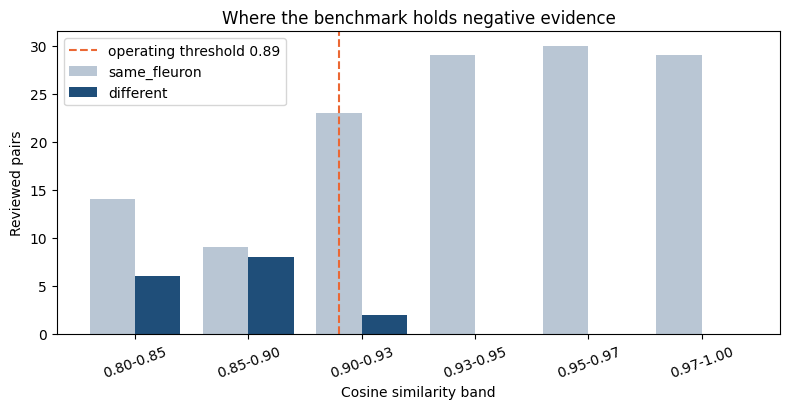

,value
operating_threshold,0.89
negatives_total,16.00
negatives_at_or_above_threshold,2.00
calibration_negatives_above,2.00
evaluation_negatives_above,0.00
pairs_at_or_above_threshold,125.00


In [5]:
# The threshold selected above is the similarity at which this chapter treats two crops as the
# same design. Precision can only be observed where negative pairs exist, so the question is how
# many of them sit at or above that threshold, which is the region where a false merge happens.
above = reviewed_pairs.similarity >= SELECTED_SIMILARITY_THRESHOLD
negative_mask = reviewed_pairs.label.eq('different')

negatives_above_threshold = pd.DataFrame([{
    'operating_threshold': SELECTED_SIMILARITY_THRESHOLD,
    'negatives_total': int(negative_mask.sum()),
    'negatives_at_or_above_threshold': int((negative_mask & above).sum()),
    'calibration_negatives_above': int((negative_mask & above
                                        & reviewed_pairs.benchmark_split.eq('calibration')).sum()),
    'evaluation_negatives_above': int((negative_mask & above
                                       & reviewed_pairs.benchmark_split.eq('evaluation')).sum()),
    'pairs_at_or_above_threshold': int(above.sum()),
}])
negatives_above_threshold.to_csv(OUTPUT_DIR / 'negatives_above_threshold.csv', index=False)

band_negatives = (reviewed_pairs[negative_mask].groupby('similarity_bin').size()
                  .reindex(sorted(reviewed_pairs.similarity_bin.unique()), fill_value=0))
band_positives = (reviewed_pairs[reviewed_pairs.label.eq('same_fleuron')]
                  .groupby('similarity_bin').size()
                  .reindex(band_negatives.index, fill_value=0))

figure, axis = plt.subplots(figsize=(8, 4.2))
positions = np.arange(len(band_negatives))
axis.bar(positions - 0.2, band_positives.values, width=0.4, label='same_fleuron', color='#b9c6d4')
axis.bar(positions + 0.2, band_negatives.values, width=0.4, label='different', color='#1f4e79')
band_lower = np.array([float(str(b).split('-')[0]) for b in band_negatives.index])
threshold_position = np.interp(
    SELECTED_SIMILARITY_THRESHOLD, band_lower, positions, left=-0.5, right=len(positions) - 0.5)
axis.axvline(threshold_position, color='#eb6834', linestyle='--',
             label=f'operating threshold {SELECTED_SIMILARITY_THRESHOLD:g}')
axis.set_xticks(positions)
axis.set_xticklabels(band_negatives.index, rotation=20)
axis.set(xlabel='Cosine similarity band', ylabel='Reviewed pairs',
         title='Where the benchmark holds negative evidence')
axis.legend()
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'negatives_by_band.png', dpi=180, bbox_inches='tight')
plt.show()
display(negatives_above_threshold.T.rename(columns={0: 'value'}))

**Takeaway.** A single threshold of 0.89 reaches precision 1.000 and recall 0.881 on the held-out
pairs, so the representation supports identity decisions and the rest of the notebook is measuring
the grouping rather than the descriptor.

The same figures expose the annotation's limit. Of the 125 annotated pairs at or above that
threshold, two are negative, and both fall in the calibration split; the held-out split contains
none. The benchmark holds its negative evidence below the similarity region in which the clustering
makes its decisions. This is established without reference to any clustering method. What it costs
the comparison is measured in Section 7.

## 4. How every configuration is scored

One function scores both families, so the comparison is like for like. A pair counts as
predicted-same only when both crops are assigned and assigned to the same cluster, so leaving a
crop unassigned costs recall but never precision. That asymmetry is why coverage is reported beside
precision rather than after it.

Three quantities accompany precision and recall. Coverage is the share of the corpus assigned at
all. The largest-cluster share catches the degenerate solution in which nearly everything chains
into one group. The grouped rate of reviewed `non_fleuron` pairs is kept separate on purpose,
because grouping two printers' rules together is a success for the clustering and a failure for the
chapter, and must not be averaged into the identity score. Intervals are Wilson rather than normal
approximation, which matters at these counts.

The selection rule from Section 1 is implemented once, here, and applied unchanged wherever a
choice is made.

In [6]:
def evaluate_clustering(cluster_labels, pair_split):
    cluster_labels = np.asarray(cluster_labels, dtype=int)
    split_pairs = reviewed_pairs[reviewed_pairs.benchmark_split == pair_split]
    identity = split_pairs[split_pairs.label.isin(['same_fleuron', 'different'])]
    left = identity.left_index.to_numpy(dtype=int)
    right = identity.right_index.to_numpy(dtype=int)
    predicted_same = (
        (cluster_labels[left] >= 0)
        & (cluster_labels[left] == cluster_labels[right])
    )
    metrics = binary_metrics(identity.label.eq('same_fleuron'), predicted_same)

    non_fleuron = split_pairs[split_pairs.label == 'non_fleuron']
    if len(non_fleuron):
        noise_left = non_fleuron.left_index.to_numpy(dtype=int)
        noise_right = non_fleuron.right_index.to_numpy(dtype=int)
        non_fleuron_grouped_rate = float(np.mean(
            (cluster_labels[noise_left] >= 0)
            & (cluster_labels[noise_left] == cluster_labels[noise_right])
        ))
    else:
        non_fleuron_grouped_rate = np.nan

    assigned = cluster_labels >= 0
    assigned_labels = cluster_labels[assigned]
    cluster_sizes = np.bincount(assigned_labels) if len(assigned_labels) else np.array([])
    return {
        **metrics,
        'identity_pairs': int(len(identity)),
        'non_fleuron_pairs': int(len(non_fleuron)),
        'non_fleuron_grouped_rate': non_fleuron_grouped_rate,
        'assigned_candidates': int(assigned.sum()),
        'coverage': float(assigned.mean()),
        'cluster_count': int(len(np.unique(assigned_labels))) if len(assigned_labels) else 0,
        'largest_cluster': int(cluster_sizes.max()) if len(cluster_sizes) else 0,
        'largest_cluster_fraction': float(cluster_sizes.max() / len(cluster_labels)) if len(cluster_sizes) else 0.0,
    }

def select_calibration_configuration(results):
    eligible = results[
        (results.precision >= PRECISION_TARGET)
        & (results.largest_cluster_fraction <= MAX_LARGEST_CLUSTER_FRACTION)
    ]
    # The encoded constraints are enforced rather than preferred. An earlier
    # version fell back to the full pool when nothing was eligible, which would have let
    # an ineligible configuration be selected without any record that it had happened.
    assert len(eligible), (
        'No configuration met the encoded constraints. The rule cannot be '
        'applied, and selecting anyway would abandon the pre-registration.')
    return eligible.sort_values(
        ['f0_5', 'coverage', 'recall'], ascending=[False, False, False]
    ).iloc[0]

## 5. Candidate configurations

Twenty-four in total, from two families that fail in different ways. Both are scored on the
calibration pairs alone.

### 5.1 HDBSCAN on a 50-dimensional projection

Six settings of (`min_cluster_size`, `min_samples`), from (3, 1) to (10, 10). The two parameters do
different jobs: `min_cluster_size` is the smallest group the method will agree to call a cluster,
so it sets a floor on how rare a fleuron can be and still be found at all, while `min_samples`
controls how conservative the density estimate is, buying precision with coverage.

PCA to 50 dimensions is applied first because neighbour distances concentrate in high dimension,
which is exactly the contrast a density method depends on, and the projection is L2 normalised
again afterwards because PCA discards components and so does not preserve vector length.

The floor reaches beyond this notebook: a fleuron appearing fewer times than `min_cluster_size`
cannot be discovered here at all, which is why the chapter defers recurrence tables to the
retrieval stage rather than building them from the clustering.

In [7]:
PCA_PATH = OUTPUT_DIR / f'pca_{PCA_DIMENSIONS}d.npy'
if PCA_PATH.exists():
    pca_features = np.load(PCA_PATH)
else:
    pca_features = PCA(
        n_components=PCA_DIMENSIONS, svd_solver='randomized', random_state=RANDOM_SEED
    ).fit_transform(normalised_features).astype(np.float32)
    pca_features /= np.linalg.norm(pca_features, axis=1, keepdims=True) + 1e-9
    np.save(PCA_PATH, pca_features)

hdbscan_settings = [(3, 1), (3, 3), (5, 1), (5, 5), (10, 5), (10, 10)]
hdbscan_rows = []
hdbscan_label_sets = {}
for minimum_cluster_size, minimum_samples in tqdm(hdbscan_settings, desc='HDBSCAN grid'):
    config_id = f'hdbscan_mcs{minimum_cluster_size}_ms{minimum_samples}'
    labels = HDBSCAN(
        min_cluster_size=minimum_cluster_size,
        min_samples=minimum_samples,
        metric='euclidean',
        cluster_selection_method='eom',
        n_jobs=-1,
    ).fit_predict(pca_features)
    hdbscan_label_sets[config_id] = labels.astype(np.int32)
    hdbscan_rows.append({
        'method': 'HDBSCAN', 'config_id': config_id,
        'min_cluster_size': minimum_cluster_size,
        'min_samples': minimum_samples,
        **evaluate_clustering(labels, 'calibration'),
    })
hdbscan_results = pd.DataFrame(hdbscan_rows)
hdbscan_results.to_csv(OUTPUT_DIR / 'hdbscan_calibration_grid.csv', index=False)
np.savez_compressed(OUTPUT_DIR / 'hdbscan_grid_labels.npz', **hdbscan_label_sets)
best_hdbscan = select_calibration_configuration(hdbscan_results)
best_hdbscan.to_frame().T

,method,config_id,min_cluster_size,min_samples,true_positive,false_positive,false_negative,true_negative,precision,precision_ci95_lower,...,recall_ci95_upper,f0_5,identity_pairs,non_fleuron_pairs,non_fleuron_grouped_rate,assigned_candidates,coverage,cluster_count,largest_cluster,largest_cluster_fraction
4,HDBSCAN,hdbscan_mcs10_ms5,10,5,54,0,38,11,1.0,0.933584,...,0.682111,0.876623,103,16,0.0625,7160,0.329195,140,1115,0.051264


### 5.2 Mutual-kNN cores with centroid expansion

Eighteen combinations of core and expansion similarity, in two stages, each stage a defence against
a specific failure. An edge survives only where both crops list each other above the core
similarity, since mutuality stops one popular crop acting as a hub that pulls unrelated designs
together; the connected components of that strict graph become the cores. Every candidate is then
compared against the core centroids and joins the best one it clears the expansion threshold
against. Those centroids are computed once and never updated, so a newly assigned candidate cannot
drag a cluster towards itself and no chain of near neighbours can walk a cluster across a design
boundary.

Exact cosine neighbours are cached first and reused by all eighteen configurations, so the
neighbour search runs once rather than eighteen times.

In [8]:
KNN_INDICES_PATH = OUTPUT_DIR / f'knn_k{KNN_K}_indices.npy'
KNN_SIMILARITIES_PATH = OUTPUT_DIR / f'knn_k{KNN_K}_similarities.npy'

if KNN_INDICES_PATH.exists() and KNN_SIMILARITIES_PATH.exists():
    knn_indices = np.load(KNN_INDICES_PATH)
    knn_similarities = np.load(KNN_SIMILARITIES_PATH)
else:
    if DEVICE == 'cuda':
        feature_tensor = torch.from_numpy(normalised_features).to(DEVICE)
        index_parts, similarity_parts = [], []
        query_batch_size = 256
        for start in tqdm(range(0, len(feature_manifest), query_batch_size), desc='Exact kNN'):
            stop = min(start + query_batch_size, len(feature_manifest))
            query_indices = np.arange(start, stop)
            similarities = feature_tensor[start:stop] @ feature_tensor.T
            similarities[
                torch.arange(stop - start, device=DEVICE),
                torch.as_tensor(query_indices, device=DEVICE),
            ] = -torch.inf
            values, indices = torch.topk(similarities, k=KNN_K, dim=1)
            index_parts.append(indices.cpu().numpy().astype(np.int32))
            similarity_parts.append(values.cpu().numpy().astype(np.float32))
        del feature_tensor
        knn_indices = np.vstack(index_parts)
        knn_similarities = np.vstack(similarity_parts)
    else:
        from sklearn.neighbors import NearestNeighbors
        neighbor_model = NearestNeighbors(
            n_neighbors=KNN_K + 1, metric='cosine', n_jobs=-1
        ).fit(normalised_features)
        distances, raw_indices = neighbor_model.kneighbors(normalised_features)
        knn_indices = np.empty((len(feature_manifest), KNN_K), dtype=np.int32)
        knn_similarities = np.empty((len(feature_manifest), KNN_K), dtype=np.float32)
        for row_index in range(len(feature_manifest)):
            keep = raw_indices[row_index] != row_index
            knn_indices[row_index] = raw_indices[row_index][keep][:KNN_K]
            knn_similarities[row_index] = (1.0 - distances[row_index][keep][:KNN_K])
    np.save(KNN_INDICES_PATH, knn_indices)
    np.save(KNN_SIMILARITIES_PATH, knn_similarities)

assert knn_indices.shape == knn_similarities.shape == (len(feature_manifest), KNN_K)
assert np.isfinite(knn_similarities).all()
print('kNN cache:', knn_indices.shape)

kNN cache: (21750, 20)


In [9]:
def graph_cluster_labels(core_similarity, expansion_similarity):
    row_indices = np.repeat(np.arange(len(feature_manifest)), KNN_K)
    column_indices = knn_indices.reshape(-1)
    similarities = knn_similarities.reshape(-1)
    keep_edges = similarities >= core_similarity
    directed_graph = csr_matrix(
        (np.ones(int(keep_edges.sum()), dtype=np.uint8),
         (row_indices[keep_edges], column_indices[keep_edges])),
        shape=(len(feature_manifest), len(feature_manifest)),
    )
    mutual_graph = directed_graph.minimum(directed_graph.T)
    _, component_labels = connected_components(mutual_graph, directed=False)
    component_sizes = np.bincount(component_labels)
    core_components = np.where(component_sizes >= 2)[0]
    if not len(core_components):
        return np.full(len(feature_manifest), -1, dtype=np.int32)

    centroids = np.vstack([
        normalised_features[component_labels == component].mean(axis=0)
        for component in core_components
    ]).astype(np.float32)
    centroids /= np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9

    best_cluster = np.empty(len(feature_manifest), dtype=np.int32)
    best_similarity = np.empty(len(feature_manifest), dtype=np.float32)
    assignment_batch_size = 1024
    if DEVICE == 'cuda':
        feature_tensor = torch.from_numpy(normalised_features).to(DEVICE)
        centroid_tensor = torch.from_numpy(centroids).to(DEVICE)
        for start in range(0, len(feature_manifest), assignment_batch_size):
            stop = min(start + assignment_batch_size, len(feature_manifest))
            values, indices = torch.max(feature_tensor[start:stop] @ centroid_tensor.T, dim=1)
            best_cluster[start:stop] = indices.cpu().numpy()
            best_similarity[start:stop] = values.cpu().numpy()
        del feature_tensor, centroid_tensor
    else:
        for start in range(0, len(feature_manifest), assignment_batch_size):
            stop = min(start + assignment_batch_size, len(feature_manifest))
            scores = normalised_features[start:stop] @ centroids.T
            best_cluster[start:stop] = scores.argmax(axis=1)
            best_similarity[start:stop] = scores.max(axis=1)
    best_cluster[best_similarity < expansion_similarity] = -1
    return best_cluster

core_thresholds = [0.97, 0.98, 0.99]
expansion_thresholds = [0.90, 0.92, 0.94, 0.95, 0.96, 0.97]
graph_rows = []
graph_label_sets = {}
for core_similarity in tqdm(core_thresholds, desc='Graph core thresholds'):
    for expansion_similarity in expansion_thresholds:
        if expansion_similarity > core_similarity:
            continue
        config_id = f'graph_core{core_similarity:.2f}_expand{expansion_similarity:.2f}'
        labels = graph_cluster_labels(core_similarity, expansion_similarity)
        graph_label_sets[config_id] = labels.astype(np.int32)
        graph_rows.append({
            'method': 'mutual-kNN + centroid', 'config_id': config_id,
            'core_similarity': core_similarity,
            'expansion_similarity': expansion_similarity,
            **evaluate_clustering(labels, 'calibration'),
        })
graph_results = pd.DataFrame(graph_rows)
graph_results.to_csv(OUTPUT_DIR / 'graph_calibration_grid.csv', index=False)
np.savez_compressed(OUTPUT_DIR / 'graph_grid_labels.npz', **graph_label_sets)
best_graph = select_calibration_configuration(graph_results)
best_graph.to_frame().T

,method,config_id,core_similarity,expansion_similarity,true_positive,false_positive,false_negative,true_negative,precision,precision_ci95_lower,...,recall_ci95_upper,f0_5,identity_pairs,non_fleuron_pairs,non_fleuron_grouped_rate,assigned_candidates,coverage,cluster_count,largest_cluster,largest_cluster_fraction
0,mutual-kNN + centroid,graph_core0.97_expand0.90,0.97,0.9,45,0,47,11,1.0,0.921346,...,0.589647,0.827206,103,16,0.125,10972,0.50446,781,389,0.017885


## 6. Selection, and the held-out pairs opened once

The rule is applied within each family and then between the two family winners. Because the
criterion is a lexicographic total order applied identically at both levels, this is equivalent to
ranking all twenty-four configurations at once. The choice is frozen before the evaluation split is
opened, and that split is used once, here, to report rather than to choose.

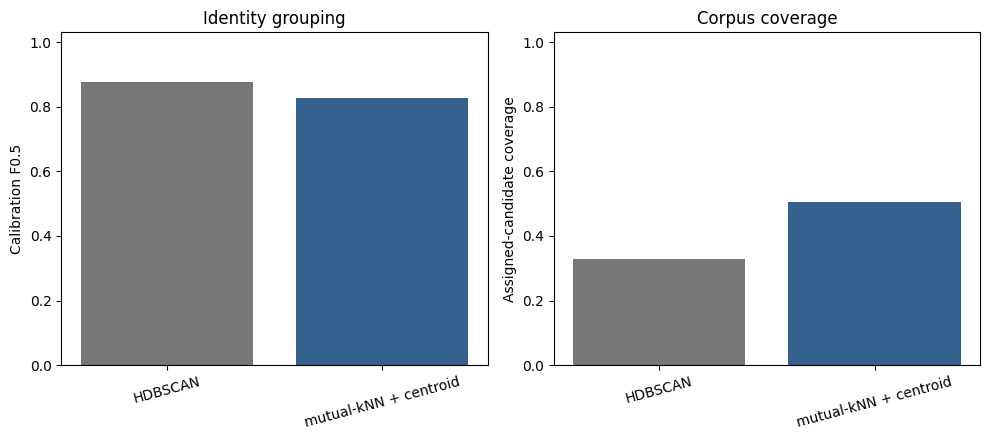

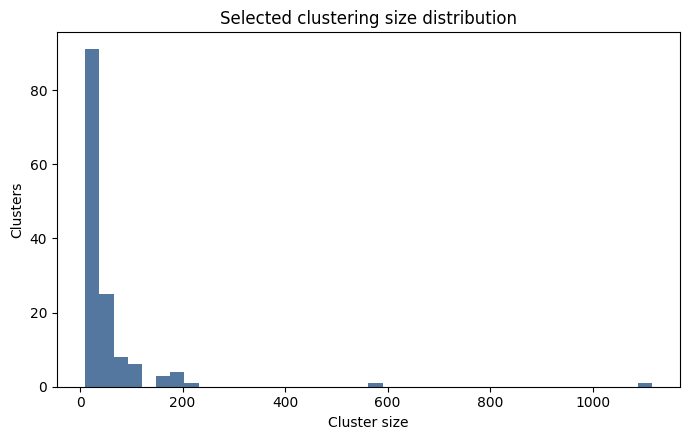

Selected: HDBSCAN hdbscan_mcs10_ms5
Calibration: {'precision': 1.0, 'recall': 0.5869565217391305, 'f0_5': 0.8766233766233766, 'coverage': 0.3291954022988506}
Evaluation : {'precision': 1.0, 'recall': 0.5238095238095238, 'f0_5': 0.8461538461538461, 'coverage': 0.3291954022988506}
Clusters   : 140


In [10]:
# The same rule is applied twice: once within each family above, and once between the
# two family champions here. Because the criterion is a lexicographic total order
# applied identically at both levels, this is equivalent to ranking all 24
# configurations at once, and it is reported as two stages because that is what runs.
method_candidates = pd.DataFrame([best_hdbscan, best_graph])
selected_method_row = select_calibration_configuration(method_candidates)
selected_config_id = selected_method_row.config_id
if selected_config_id in hdbscan_label_sets:
    selected_labels = hdbscan_label_sets[selected_config_id]
else:
    selected_labels = graph_label_sets[selected_config_id]

method_candidates.to_csv(OUTPUT_DIR / 'method_calibration_comparison.csv', index=False)
evaluation_metrics = pd.DataFrame([{
    'method': selected_method_row.method,
    'config_id': selected_config_id,
    **evaluate_clustering(selected_labels, 'evaluation'),
}])
evaluation_metrics.to_csv(OUTPUT_DIR / 'selected_evaluation_metrics.csv', index=False)
np.save(OUTPUT_DIR / 'selected_cluster_labels.npy', selected_labels.astype(np.int32))

selected_manifest = feature_manifest.copy()
selected_manifest['cluster_id'] = selected_labels
selected_manifest['assigned'] = selected_manifest.cluster_id >= 0
assigned_manifest = selected_manifest[selected_manifest.assigned].copy()
cluster_rows = []
for cluster_id, cluster_members in assigned_manifest.groupby('cluster_id'):
    member_indices = cluster_members.feature_index.to_numpy(dtype=int)
    centroid = normalised_features[member_indices].mean(axis=0)
    centroid /= np.linalg.norm(centroid) + 1e-9
    centrality = normalised_features[member_indices] @ centroid
    selected_manifest.loc[cluster_members.index, 'centrality'] = centrality
    cluster_rows.append({
        'cluster_id': int(cluster_id),
        'instances': int(len(cluster_members)),
        'scans': int(cluster_members.scan_id.nunique()),
        'inferred_books': int(cluster_members.book_id.nunique()),
        'mean_centroid_similarity': float(centrality.mean()),
        'minimum_centroid_similarity': float(centrality.min()),
    })
cluster_summary = pd.DataFrame(cluster_rows).sort_values(
    ['inferred_books', 'scans', 'instances'], ascending=False
)
cluster_summary.to_csv(OUTPUT_DIR / 'selected_cluster_summary.csv', index=False)
# written once, after the centrality column exists
selected_manifest.to_csv(OUTPUT_DIR / 'selected_clusters.csv', index=False)

selected_protocol = {
    'selection_split': 'calibration',
    'precision_target': PRECISION_TARGET,
    'maximum_largest_cluster_fraction': MAX_LARGEST_CLUSTER_FRACTION,
    'selected_method': selected_method_row.method,
    'selected_config_id': selected_config_id,
    'calibration_metrics': {
        key: (value.item() if hasattr(value, 'item') else value)
        for key, value in selected_method_row.to_dict().items()
        if not pd.isna(value)
    },
    'evaluation_metrics': {
        key: (value.item() if hasattr(value, 'item') else value)
        for key, value in evaluation_metrics.iloc[0].to_dict().items()
        if not pd.isna(value)
    },
}
with (OUTPUT_DIR / 'selected_clustering_protocol.json').open('w', encoding='utf-8') as file_handle:
    json.dump(selected_protocol, file_handle, indent=2)

figure, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(method_candidates.method, method_candidates.f0_5, color=['#777777', '#355f8d'])
axes[0].set(ylabel='Calibration F0.5', ylim=(0, 1.03), title='Identity grouping')
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(method_candidates.method, method_candidates.coverage, color=['#777777', '#355f8d'])
axes[1].set(ylabel='Assigned-candidate coverage', ylim=(0, 1.03), title='Corpus coverage')
axes[1].tick_params(axis='x', rotation=15)
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'method_calibration_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

figure, axis = plt.subplots(figsize=(7, 4.5))
axis.hist(cluster_summary.instances, bins=40, color='#355f8d', alpha=0.85)
axis.set(xlabel='Cluster size', ylabel='Clusters', title='Selected clustering size distribution')
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'selected_cluster_size_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

print('Selected:', selected_method_row.method, selected_config_id)
print('Calibration:', selected_method_row[['precision', 'recall', 'f0_5', 'coverage']].to_dict())
print('Evaluation :', evaluation_metrics.iloc[0][['precision', 'recall', 'f0_5', 'coverage']].to_dict())
print('Clusters   :', len(cluster_summary))

**Takeaway.** HDBSCAN with `min_cluster_size=10` and `min_samples=5` is selected, calibration F0.5
0.877 against the graph method's 0.827. On the held-out identity pairs it reaches precision 1.000
[0.851, 1.000], recall 0.524 [0.377, 0.666] and F0.5 0.846, from 140 clusters covering 7,160
candidates, or 32.9% of the corpus.

The two figures show what the choice traded. The selected method scores higher on the identity
criterion while assigning a third of the corpus against the graph method's half, which is the
asymmetry of Section 4 made visible: caution costs recall and is never punished as imprecision. The
size histogram shows the structural constraint holding rather than binding, the largest cluster
holding 1,115 crops, 5.1% of the corpus, well inside the 10% limit.

## 7. What this comparison could and could not decide

The rule chose a configuration. This section asks a different question: which differences between
configurations was the benchmark able to resolve at all? It reads only the two grids computed above
and the labelled pairs. It selects nothing and changes nothing.

The question has to be asked because of the way precision is estimated. A false merge can be
observed only on a pair whose true label is `different`, since grouping a pair that really is the
same design is a correct decision and says nothing about the error rate. The calibration split
holds eleven such pairs, so eleven observations carry the whole precision comparison across
twenty-four configurations. Three measurements establish what that number could support: whether
the eligibility gate could have excluded anything, how far a configuration would have had to fall
before it did, and whether the ranking separated the configurations at all.

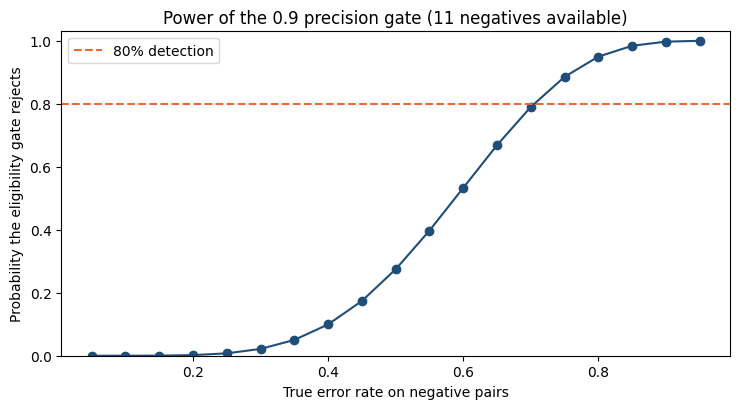

,step,surviving
0,scored on the calibration pairs,24
1,eligible: precision >= 0.9,24
2,eligible: largest cluster <= 0.1,24
3,"ranked by F0.5, then coverage, then recall",1


,value
configurations,24.000000
eligible,24.000000
zero_false_merges,20.000000
precision_minimum,0.970588
precision_maximum,1.000000
largest_cluster_maximum,0.053793
calibration_negatives,11.000000
selected_true_positives,54.000000
selected_false_merges_to_fail,7.000000
power_at_error_rate_0_5,0.274414


The selected configuration has 54 true positives, so it needs 7 false merges to fall below precision 0.9, out of 11 negative pairs available.


In [11]:
from scipy.stats import binom

grid = pd.concat([hdbscan_results, graph_results], ignore_index=True)
calibration_negatives = int(calibration_identity.label.eq('different').sum())

# --- the eligibility funnel -------------------------------------------------
precision_ok = grid.precision >= PRECISION_TARGET
size_ok = grid.largest_cluster_fraction <= MAX_LARGEST_CLUSTER_FRACTION
eligibility_funnel = pd.DataFrame([
    {'step': 'scored on the calibration pairs', 'surviving': int(len(grid))},
    {'step': f'eligible: precision >= {PRECISION_TARGET}', 'surviving': int(precision_ok.sum())},
    {'step': f'eligible: largest cluster <= {MAX_LARGEST_CLUSTER_FRACTION}',
     'surviving': int((precision_ok & size_ok).sum())},
    {'step': 'ranked by F0.5, then coverage, then recall', 'surviving': 1},
])

# --- what failing the precision gate would have required --------------------
def false_merges_to_fail(true_positive, target):
    """Smallest number of false merges that drops precision below the eligibility target.

    Counted by replicating the gate's own comparison rather than by rearranging it, so the
    answer cannot disagree with the test it describes. The closed form floor(TP*(1-t)/t)+1
    is off by one for TP=54, t=0.90, because 1 - 0.9 is not exactly 0.1 in binary.
    """
    false_positive = 0
    while true_positive / (true_positive + false_positive) >= target:
        false_positive += 1
    return false_positive


grid['false_merges_to_fail'] = [
    false_merges_to_fail(int(tp), PRECISION_TARGET) for tp in grid.true_positive]
grid['negatives_available'] = calibration_negatives
grid['share_of_negatives_needed'] = grid.false_merges_to_fail / calibration_negatives
grid.to_csv(OUTPUT_DIR / 'benchmark_detectability.csv', index=False)

selected_grid_row = grid[grid.config_id == selected_config_id].iloc[0]
merges_needed = int(selected_grid_row.false_merges_to_fail)

# --- power of the gate against a genuinely imprecise method -----------------
# With `calibration_negatives` negative pairs available, the false merges a method commits
# are Binomial(n, r) for a true error rate r on negatives. The gate rejects it only when
# at least `merges_needed` of them occur.
error_rates = np.round(np.arange(0.05, 1.00, 0.05), 2)
gate_power = pd.DataFrame({
    'true_error_rate_on_negatives': error_rates,
    'probability_gate_rejects': [
        float(binom.sf(merges_needed - 1, calibration_negatives, rate)) for rate in error_rates],
})
gate_power.to_csv(OUTPUT_DIR / 'eligibility_gate_power.csv', index=False)

# --- resolution of the ranking ----------------------------------------------
tied_at_ceiling = grid[grid.false_positive == 0]
resolution = pd.DataFrame([{
    'configurations': int(len(grid)),
    'eligible': int((precision_ok & size_ok).sum()),
    'zero_false_merges': int(len(tied_at_ceiling)),
    'precision_minimum': float(grid.precision.min()),
    'precision_maximum': float(grid.precision.max()),
    'largest_cluster_maximum': float(grid.largest_cluster_fraction.max()),
    'calibration_negatives': calibration_negatives,
    'selected_true_positives': int(selected_grid_row.true_positive),
    'selected_false_merges_to_fail': merges_needed,
    'power_at_error_rate_0_5': float(binom.sf(merges_needed - 1, calibration_negatives, 0.5)),
}])
resolution.to_csv(OUTPUT_DIR / 'benchmark_resolution.csv', index=False)

figure, axis = plt.subplots(figsize=(7.5, 4.2))
axis.plot(gate_power.true_error_rate_on_negatives, gate_power.probability_gate_rejects,
          marker='o', color='#1f4e79')
axis.axhline(0.8, color='#eb6834', linestyle='--', label='80% detection')
axis.set(xlabel='True error rate on negative pairs',
         ylabel='Probability the eligibility gate rejects',
         ylim=(0, 1.03),
         title=f'Power of the {PRECISION_TARGET:g} precision gate '
               f'({calibration_negatives} negatives available)')
axis.legend()
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'eligibility_gate_power.png', dpi=180, bbox_inches='tight')
plt.show()

display(eligibility_funnel)
display(resolution.T.rename(columns={0: 'value'}))
print(f'The selected configuration has {int(selected_grid_row.true_positive)} true positives, so it '
      f'needs {merges_needed} false merges to fall below precision {PRECISION_TARGET:g}, '
      f'out of {calibration_negatives} negative pairs available.')

**Takeaway.** Precision could be observed on eleven pairs, nearly every configuration scored
perfectly on them, and a measure that weights precision four times over recall therefore ranked on
recall alone. The paragraphs below establish that in order.

**Neither eligibility constraint removed a candidate.** All twenty-four cleared the precision gate
and all stayed far below the largest-cluster limit, so the funnel narrows only at the ranking step.
That on its own is ambiguous: it is equally consistent with every configuration being precise and
with the benchmark being unable to tell.

**The detectability calculation settles it.** The selected configuration would have needed seven
false merges out of the eleven available negatives before the gate excluded it. A configuration
that misjudged six of eleven, more than half, would still have passed as eligible. The gate could
only ever have caught a catastrophically imprecise method.

**The power curve puts a number on that.** Against a method with a true error rate of 0.5 on
negative pairs, the gate rejects roughly a quarter of the time, and it does not reach 80% detection
until the true error rate approaches 0.7. This holds regardless of how precise the twenty-four
configurations actually were, because it is a property of the instrument.

**The ranking has no resolution either.** Twenty of the twenty-four produced no false merge at all,
so their precision is identically 1.000 and their Wilson intervals overlap completely. With
precision effectively constant across the grid, F0.5 varies almost entirely with recall, and the
configuration the rule selected is the one with the highest recall in the grid.

A rule written to weight precision four times as heavily as recall therefore selected on recall.
The arithmetic is sound and the rule was applied exactly as written; what failed is the evidence
available to it.

### 7.1 Would either gate value have changed the answer?

The two constraints are guards rather than tuned parameters: the precision gate is a floor on
acceptable purity, and the largest-cluster gate refuses the degenerate solution in which a method
collects most of the corpus into one group. Neither excluded a configuration above, so the question
is whether their particular values did any work. Each is swept across its range below while the
other is held as encoded, and the same lexicographic rule is applied at every value.


In [12]:
# Each gate swept across its range, the other held as encoded, the same rule applied throughout.
def winner_under(precision_target, largest_cluster_limit):
    """The configuration the rule selects when the two gates are moved."""
    eligible = grid[(grid.precision >= precision_target)
                    & (grid.largest_cluster_fraction <= largest_cluster_limit)]
    if not len(eligible):
        return 'none eligible'
    return eligible.sort_values(['f0_5', 'coverage', 'recall'],
                                ascending=False).iloc[0].config_id


sensitivity = pd.DataFrame(
    [{'gate': 'precision', 'value': value,
      'selected': winner_under(value, MAX_LARGEST_CLUSTER_FRACTION)}
     for value in [0.00, 0.50, 0.80, 0.90, 0.95, 0.97, 0.99, 1.00]]
    + [{'gate': 'largest cluster', 'value': value,
        'selected': winner_under(PRECISION_TARGET, value)}
       for value in [0.03, 0.05, 0.06, 0.10, 0.20, 0.50, 1.00]])
sensitivity.to_csv(OUTPUT_DIR / 'gate_sensitivity.csv', index=False)

print(f'precision across the grid        : {grid.precision.min():.3f} to '
      f'{grid.precision.max():.3f}  ({int((grid.precision >= 0.9999).sum())} of '
      f'{len(grid)} configurations at 1.000)')
print(f'largest-cluster fraction         : {grid.largest_cluster_fraction.min():.3f} to '
      f'{grid.largest_cluster_fraction.max():.3f}  (limit {MAX_LARGEST_CLUSTER_FRACTION})\n')
for gate, part in sensitivity.groupby('gate', sort=False):
    print(f'selected configuration as the {gate} gate moves, the other held as encoded')
    for row in part.itertuples(index=False):
        print(f'    {row.value:>5.2f}   {row.selected}')
    print()

precision across the grid        : 0.971 to 1.000  (20 of 24 configurations at 1.000)
largest-cluster fraction         : 0.001 to 0.054  (limit 0.1)

selected configuration as the precision gate moves, the other held as encoded
     0.00   hdbscan_mcs10_ms5
     0.50   hdbscan_mcs10_ms5
     0.80   hdbscan_mcs10_ms5
     0.90   hdbscan_mcs10_ms5
     0.95   hdbscan_mcs10_ms5
     0.97   hdbscan_mcs10_ms5
     0.99   hdbscan_mcs10_ms5
     1.00   hdbscan_mcs10_ms5

selected configuration as the largest cluster gate moves, the other held as encoded
     0.03   graph_core0.97_expand0.90
     0.05   hdbscan_mcs5_ms5
     0.06   hdbscan_mcs10_ms5
     0.10   hdbscan_mcs10_ms5
     0.20   hdbscan_mcs10_ms5
     0.50   hdbscan_mcs10_ms5
     1.00   hdbscan_mcs10_ms5



**Takeaway.** Neither value did any work. The rule selects `hdbscan_mcs10_ms5` at **every**
precision gate from 0.00 to 1.00, because the selected configuration commits no false merge on the
calibration negatives and the four configurations that do commit one score lower on F0.5 in any
case. The largest-cluster gate is equally inert above 0.06, and only rearranges the ranking below
the selected configuration's own largest cluster of 5.1%.

This is a stronger statement than declaring the values in advance. Declaring them in advance shows
they were not adjusted after the grid was seen; the sweep shows that adjusting them could not have
changed the outcome anywhere in their range. The constraints are still worth stating, because the
largest-cluster gate is load bearing against a candidate outside this grid: `4_MethodComparison`
finds connected components placing 83% of the corpus in one component, and that gate is what
rejects it.

## 8. Conclusions, and the two questions this benchmark cannot answer

**The representation carries identity signal.** A single cosine threshold of 0.89 reaches precision
1.000 and recall 0.881 on the held-out pairs, so a bare threshold recovers most matches without an
evident false merge. That is what the stage needs before a grouping method is worth building. How
precisely it separates is bounded by the five held-out negatives rather than established by them,
and the 12% of same-design pairs falling below the threshold are a floor any method built on this
similarity inherits rather than a fault it introduces.

**HDBSCAN was selected**, `min_cluster_size=10` and `min_samples=5` on the 50-dimensional
projection, with calibration F0.5 0.877 against the best mutual-kNN configuration's 0.827. Both
families reached calibration precision 1.000, so the margin is entirely in recall. The choice was
frozen before the evaluation split was opened, and Section 7 states what that margin was worth as
evidence.

**The frozen result** is precision 1.000 [0.851, 1.000], recall 0.524 [0.377, 0.666] and F0.5 0.846
on the held-out identity pairs, from a clustering of 140 clusters covering 7,160 candidates, 32.9%
of the corpus. Recall is the informative figure of the two; the precision estimate rests on five
negative pairs.

**One family was never in the grid.** Connected components on a thresholded similarity graph was
excluded at pre-registration on the assumption that it would chain, and the mutual-kNN method of
Section 5.2 was designed to avoid precisely that. The assumption was stated but never measured, so
the comparison above is incomplete in a way its own numbers cannot reveal. The notebook that
follows measures the assumption and scores all three methods together.

**Two questions follow, and they are not the same question.**

The first is about the *sampling frame*, and it is the stronger one. This benchmark scores pairs
drawn by similarity from the whole corpus. What a catalogue depends on is a different quantity: of
the pairs the method actually merged, how many are wrong. Those are different conditional
probabilities, and no amount of further labelling of similarity-sampled pairs would answer the
second. Answering it requires sampling from the clustering's own output, which is what
`6_WithinClusterAudit` does.

The second is about *statistical power*, and Section 7 measures it. Sixteen negatives in total,
eleven in the split that chooses and five in the split that reports, with almost none above the
operating threshold. The benchmark can calibrate a threshold and select parameters. It cannot
evaluate precision, and it cannot establish that two methods differ. Answering that requires negatives in
bulk, which the notebook that follows obtains by labelling the pairs on which the candidate methods
disagree.

Both instruments are built after this notebook, and neither is used to revisit the selection made
in it. Evaluating a frozen choice is evidence; re-making it with knowledge of the answer would
abandon the pre-registration.

## 9. Review material for the next stage

The analysis is complete. What follows renders the clustering for human inspection, because an
annotation of 180 pairs cannot speak for 21,750 crops, and every later human step in the chapter
reads these sheets rather than the label array.

### 9.1 First qualitative check of the twenty most widely recurring clusters

Each sheet shows the twenty-four most central members of one cluster. The verdicts recorded against
them are read from the frozen annotation rather than regenerated, on the same principle as the pair
labels: a human judgement is an input, not an output of a re-run.

This is a qualitative check and not a measurement. The sheets show central members only, which
flatters every cluster, and the blind stratified audit in `6_WithinClusterAudit` supersedes it. Its
one durable result is compositional: seven of these twenty clusters are recurring non-fleuron material
rather than ornaments, covering 1,761 crops, which is why the chapter filters the shortlist
by curated overlap before treating any cluster as a fleuron.

In [13]:
for stale_sheet in CLUSTER_SHEETS_DIR.glob('cluster_*.png'):
    stale_sheet.unlink()

review_cluster_ids = cluster_summary.head(20).cluster_id.tolist()
review_inventory = cluster_summary.head(20).copy().reset_index(drop=True)
review_inventory.insert(0, 'sheet_id', [f'H{rank + 1:02d}' for rank in range(len(review_inventory))])
review_inventory.insert(1, 'sheet_file', [
    f'cluster_{rank + 1:02d}_id{int(cluster_id)}.png'
    for rank, cluster_id in enumerate(review_inventory.cluster_id)
])
review_path = OUTPUT_DIR / 'selected_cluster_review.csv'
annotation_columns = ['label', 'estimated_imposters', 'notes']
# The verdicts are a human judgement, so they are an input like the pair labels: read from
# the frozen annotation when one exists, so that a re-run reports them instead of emitting a
# blank sheet. Only the assembled table is written to this run's output directory.
frozen_review_path = BENCHMARK_DIR / 'method_comparison' / 'selected_cluster_review.csv'
review_source_path = frozen_review_path if frozen_review_path.exists() else review_path
if review_source_path.exists():
    previous_review = pd.read_csv(review_source_path, keep_default_na=False)
    retained_columns = [
        column for column in annotation_columns if column in previous_review.columns
    ]
    review_inventory = review_inventory.merge(
        previous_review[['cluster_id', *retained_columns]],
        on='cluster_id', how='left', validate='one_to_one',
    )
for column in annotation_columns:
    if column not in review_inventory.columns:
        review_inventory[column] = ''
    review_inventory[column] = review_inventory[column].fillna('')
review_inventory.to_csv(review_path, index=False)
completed_review = review_inventory[review_inventory.label.ne('')]
if len(completed_review):
    review_summary = (
        completed_review.groupby('label', as_index=False)
        .agg(sheets=('sheet_id', 'count'), represented_instances=('instances', 'sum'))
        .sort_values('sheets', ascending=False)
    )
else:
    review_summary = pd.DataFrame(columns=['label', 'sheets', 'represented_instances'])
review_summary.to_csv(OUTPUT_DIR / 'selected_cluster_review_summary.csv', index=False)
for rank, cluster_id in enumerate(tqdm(review_cluster_ids, desc='Cluster sheets')):
    members = (
        selected_manifest[selected_manifest.cluster_id == cluster_id]
        .sort_values('centrality', ascending=False)
        .head(24)
    )
    figure, axes = plt.subplots(3, 8, figsize=(12, 5.2))
    for axis in axes.flat:
        axis.axis('off')
    for axis, member in zip(axes.flat, members.itertuples(index=False)):
        with Image.open(PROJECT_DIR / member.crop_path) as crop_image:
            axis.imshow(crop_image.convert('RGB'))
        axis.set_title(f'{member.centrality:.2f}', fontsize=7)
    summary_row = cluster_summary[cluster_summary.cluster_id == cluster_id].iloc[0]
    figure.suptitle(
        f'Cluster {int(cluster_id)} — {int(summary_row.instances)} instances, '
        f'{int(summary_row.scans)} scans, {int(summary_row.inferred_books)} inferred books',
        fontsize=11,
    )
    figure.tight_layout()
    figure.savefig(
        CLUSTER_SHEETS_DIR / f'cluster_{rank + 1:02d}_id{int(cluster_id)}.png',
        dpi=150, bbox_inches='tight',
    )
    plt.close(figure)

print(f'Wrote {len(review_cluster_ids)} sheets to {CLUSTER_SHEETS_DIR}')

Wrote 20 sheets to <project>/2_clustering_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_clustering_benchmark_v1/method_comparison_rerun1/selected_cluster_sheets


### 9.2 Complete gallery of the selected clustering

One sheet for every cluster, showing the twelve most central members beside the twelve least
central, each captioned with its centrality. The layout is the point. A sheet of central members
alone agrees with itself by construction, so placing the weakest members beside them is what makes
a false merge visible at a glance. `6_WithinClusterAudit` links these sheets into its triage folders
and draws its audit pairs along the same core-to-edge axis.

In [14]:
ALL_CLUSTER_SHEETS_DIR = OUTPUT_DIR / 'all_selected_cluster_sheets'
ALL_CLUSTER_SHEETS_DIR.mkdir(parents=True, exist_ok=True)
gallery_manifest = pd.read_csv(OUTPUT_DIR / 'selected_clusters.csv')
gallery_summary = pd.read_csv(OUTPUT_DIR / 'selected_cluster_summary.csv')
gallery_rows = []

for rank, summary_row in enumerate(tqdm(
    gallery_summary.itertuples(index=False),
    total=len(gallery_summary),
    desc='Complete cluster gallery',
)):
    cluster_id = int(summary_row.cluster_id)
    cluster_members = (
        gallery_manifest[gallery_manifest.cluster_id == cluster_id]
        .sort_values('centrality', ascending=False)
    )
    core_members = cluster_members.head(12).copy()
    boundary_members = cluster_members.drop(core_members.index).tail(12).copy()
    core_members['sample_role'] = 'core'
    boundary_members['sample_role'] = 'edge'
    displayed_members = pd.concat([core_members, boundary_members])

    figure, axes = plt.subplots(3, 8, figsize=(12, 5.2))
    for axis in axes.flat:
        axis.axis('off')
    for axis, member in zip(axes.flat, displayed_members.itertuples(index=False)):
        with Image.open(PROJECT_DIR / member.crop_path) as crop_image:
            axis.imshow(crop_image.convert('RGB'))
        axis.set_title(f'{member.sample_role} {member.centrality:.2f}', fontsize=7)
    figure.suptitle(
        f'Cluster {cluster_id} — {int(summary_row.instances)} instances, '
        f'{int(summary_row.scans)} scans, {int(summary_row.inferred_books)} inferred books',
        fontsize=11,
    )
    figure.tight_layout()
    sheet_file = f'G{rank + 1:03d}_cluster_id{cluster_id}.png'
    figure.savefig(ALL_CLUSTER_SHEETS_DIR / sheet_file, dpi=130, bbox_inches='tight')
    plt.close(figure)
    gallery_rows.append({
        'sheet_id': f'G{rank + 1:03d}',
        'sheet_file': sheet_file,
        'cluster_id': cluster_id,
        'instances': int(summary_row.instances),
        'scans': int(summary_row.scans),
        'inferred_books': int(summary_row.inferred_books),
        'mean_centroid_similarity': float(summary_row.mean_centroid_similarity),
        'minimum_centroid_similarity': float(summary_row.minimum_centroid_similarity),
        'displayed_core_members': int(len(core_members)),
        'displayed_boundary_members': int(len(boundary_members)),
    })

gallery_inventory = pd.DataFrame(gallery_rows)
gallery_inventory.to_csv(OUTPUT_DIR / 'all_selected_cluster_gallery.csv', index=False)
print(f'Wrote {len(gallery_inventory)} sheets to {ALL_CLUSTER_SHEETS_DIR}')

Wrote 140 sheets to <project>/2_clustering_outputs/all_regions_v1_minside24_dinov2_vitb14_binarized_v1_clustering_benchmark_v1/method_comparison_rerun1/all_selected_cluster_sheets
